# 03 - Correlation Matrices Dataset (PyTorch)
In this notebook we build a PyTorch dataset of correlation matrices computed on rolling windows.

We create sliding-window in order to directly compute the correlation matrices from the cleaned quotation matrix (`filtered_data.csv`).

To compute how many samples (i.e., windows/correlation matrices) you will obtain from your dataset, the formula is straightforward.

Let:
- $N$: total number of rows (days) in the dataset.
- $W$: window size (`WINDOW_LENGTH`).
- $S$: step between consecutive windows (`STRIDE`).

The formula for the number of windows $N_{windows}$ is:

$$
N_{windows} = \left\lfloor \frac{N - W}{S} \right\rfloor + 1
$$

In [12]:
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

In [2]:
# Editable parameters
DATA_PATH = Path('../data/processed/filtered_data.csv')
WINDOW_LENGTH = 60
STRIDE = 1
DTYPE = torch.float32

df = pd.read_csv(DATA_PATH)

print(f'(Rows, Columns) = (Days, Quotations) = {df.shape}')
df.head()

(Rows, Columns) = (Days, Quotations) = (1258, 333)


,BBY,CSCO,TSN,KMI,GT,DLTR,IVZ,PFE,GD,EQR,...,XEL,IR,CCI,DUK,JEC,NUE,BIIB,MSI,RHT,VMC
0,14.313087,17.893888,21.696400,30.784206,12.417879,45.185,23.100399,23.138992,61.404850,40.617558,...,24.195093,38.409443,61.060830,57.073170,48.313774,39.015694,166.34,56.243200,50.81,49.740070
1,14.967250,17.872437,22.184496,30.941988,12.393971,46.110,23.134890,23.155901,61.188030,40.838947,...,24.203524,37.884186,61.358260,57.073170,47.482826,38.426777,168.70,56.080463,51.58,50.775303
2,15.499302,17.795216,22.213210,31.174510,12.116636,46.480,23.678123,23.409525,60.564674,41.067715,...,24.532307,38.000908,62.084343,57.452282,47.769703,38.989710,169.96,56.505386,52.08,50.882732
3,16.048800,18.205347,22.328054,31.108076,12.240958,46.000,23.885070,23.730783,61.133823,41.429317,...,24.641901,38.839863,62.635464,57.823154,49.490955,39.327473,171.31,56.930305,51.99,52.435585
4,16.354074,18.631780,22.557747,30.701162,12.336591,45.470,23.954052,23.773054,61.142860,41.591670,...,24.532307,38.985767,63.099106,57.592392,49.698692,40.262810,172.45,57.056877,52.80,52.250023


In [3]:
def build_correlation_windows(
    frame: pd.DataFrame,
    window_length: int,
    stride: int = 1,
    dtype: torch.dtype = torch.float32
) -> Tuple[torch.Tensor, List[Tuple[int, int]]]:
    
    # Check if there are enough rows for the sliding window
    n_rows = len(frame)
    if n_rows < window_length:
        raise ValueError(f"Dataset too short ({n_rows} rows) for a window_length of {window_length}")

    corr_mats = []
    windows = []

    # Iterate through time windows
    for start in range(0, n_rows - window_length + 1, stride):
        end = start + window_length
        
        # Extract the window and calculate price correlation
        # .corr() defaults to Pearson correlation between columns
        window_corr = frame.iloc[start:end].corr()
        
        # Convert to PyTorch Tensor
        corr_mats.append(torch.tensor(window_corr.values, dtype=dtype))
        windows.append((start, end))

    # Return the full stack (stack converts the list into a single 3D tensor)
    return torch.stack(corr_mats), windows

In [4]:
class RollingCorrelationDataset(Dataset):
    def __init__(
        self,
        frame: pd.DataFrame,
        window_length: int,
        stride: int = 1,
        dtype: torch.dtype = torch.float32,
    ) -> None:
        self.tensor, self.window_ranges = build_correlation_windows(
            frame=frame,
            window_length=window_length,
            stride=stride,
            dtype=dtype,
        )

    def __len__(self) -> int:
        return self.tensor.size(0)

    def __getitem__(self, idx: int):
        corr = self.tensor[idx]
        start, end = self.window_ranges[idx]
        return {
            'corr': corr,
            'window_start': start,
            'window_end': end,
        }

In [5]:
dataset = RollingCorrelationDataset(
    frame=df,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
    dtype=DTYPE,
    )

print(f'Number of windows: {len(dataset)}')
print(f'Single element shape: {dataset[0]["corr"].shape}')
print(f'Full tensor shape: {dataset.tensor.shape}')

sample = dataset[0]
sample

Number of windows: 1199
Single element shape: torch.Size([333, 333])
Full tensor shape: torch.Size([1199, 333, 333])


{'corr': tensor([[ 1.0000,  0.2411,  0.6605,  ..., -0.5672, -0.1637, -0.0180],
         [ 0.2411,  1.0000,  0.3510,  ..., -0.2058,  0.5224,  0.4972],
         [ 0.6605,  0.3510,  1.0000,  ..., -0.6284,  0.0037,  0.2478],
         ...,
         [-0.5672, -0.2058, -0.6284,  ...,  1.0000, -0.1371, -0.2324],
         [-0.1637,  0.5224,  0.0037,  ..., -0.1371,  1.0000,  0.7064],
         [-0.0180,  0.4972,  0.2478,  ..., -0.2324,  0.7064,  1.0000]]),
 'window_start': 0,
 'window_end': 60}

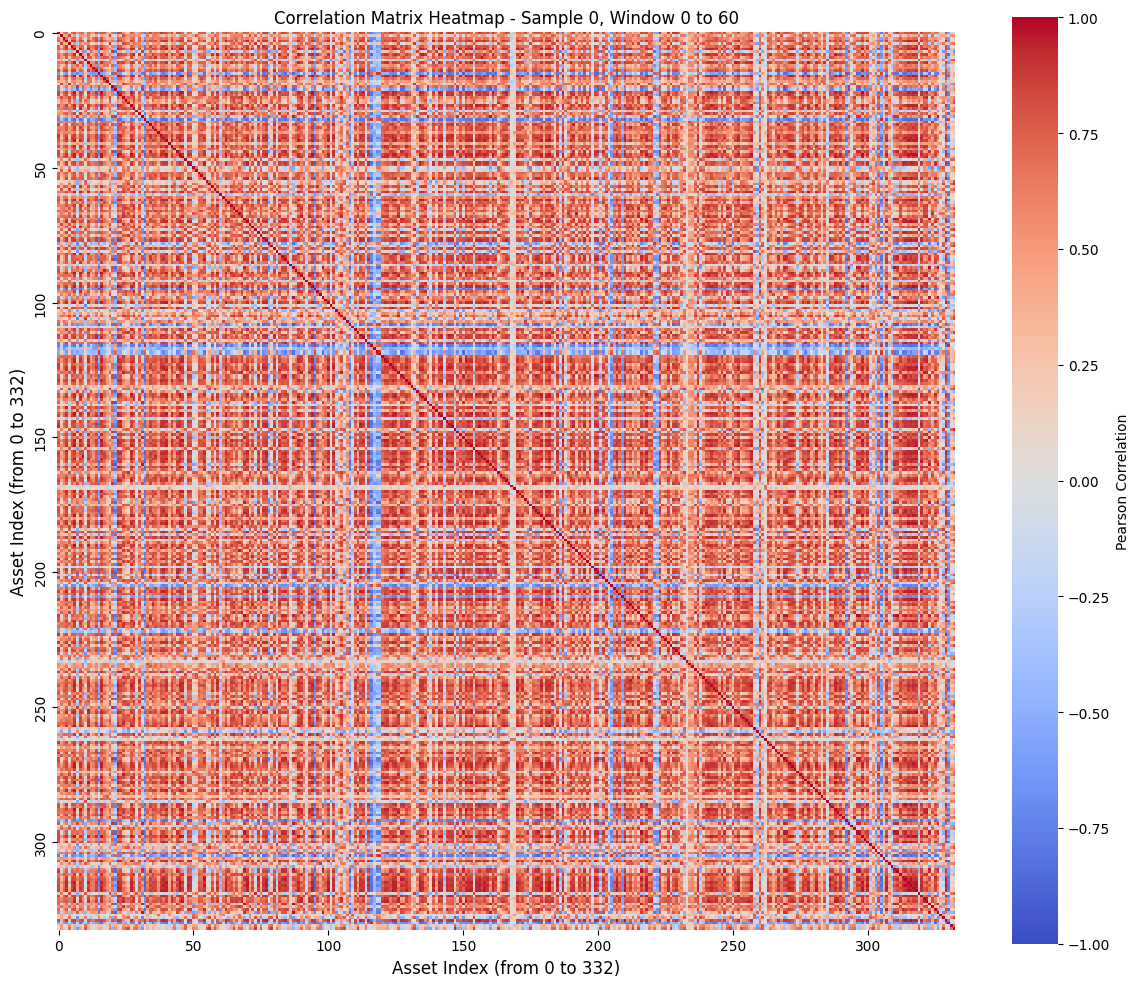

In [9]:
# Extract and convert correlation matrix to numpy
idx_sample = 0
corr_matrix = dataset[idx_sample]["corr"].numpy()
num_assets = corr_matrix.shape[0]

plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(
    corr_matrix, 
    annot=False, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    square=True,
    xticklabels=50, 
    yticklabels=50,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title(f'Correlation Matrix Heatmap - Sample {idx_sample}, Window {dataset[idx_sample]["window_start"]} to {dataset[idx_sample]["window_end"]}')
plt.xlabel('Asset Index (from 0 to 332)', fontsize=12)
plt.ylabel('Asset Index (from 0 to 332)', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
print(dataset[0]["corr"][0:10,0:10])

tensor([[ 1.0000,  0.2411,  0.6605,  0.7302,  0.1422,  0.7410,  0.7787,  0.5105,  0.7167,  0.7270],
        [ 0.2411,  1.0000,  0.3510,  0.4443,  0.8431,  0.2286,  0.5477, -0.0447,  0.5187,  0.4983],
        [ 0.6605,  0.3510,  1.0000,  0.6960,  0.3767,  0.6614,  0.7191,  0.2153,  0.7162,  0.4088],
        [ 0.7302,  0.4443,  0.6960,  1.0000,  0.3532,  0.8856,  0.8645,  0.4825,  0.8081,  0.7832],
        [ 0.1422,  0.8431,  0.3767,  0.3532,  1.0000,  0.1666,  0.5160, -0.3282,  0.5831,  0.2774],
        [ 0.7410,  0.2286,  0.6614,  0.8856,  0.1666,  1.0000,  0.7940,  0.4810,  0.7317,  0.6811],
        [ 0.7787,  0.5477,  0.7191,  0.8645,  0.5160,  0.7940,  1.0000,  0.2558,  0.9353,  0.7241],
        [ 0.5105, -0.0447,  0.2153,  0.4825, -0.3282,  0.4810,  0.2558,  1.0000,  0.1154,  0.6515],
        [ 0.7167,  0.5187,  0.7162,  0.8081,  0.5831,  0.7317,  0.9353,  0.1154,  1.0000,  0.5951],
        [ 0.7270,  0.4983,  0.4088,  0.7832,  0.2774,  0.6811,  0.7241,  0.6515,  0.5951,  1.0000]])

In [16]:
#  Save of the correlation tensor
OUTPUT_TENSOR_PATH = Path('../data/processed/corr_windows_tensor.pt')
torch.save(
    {
        'corr_tensor': dataset.tensor,
        'window_ranges': dataset.window_ranges,
        'window_length': WINDOW_LENGTH,
        'stride': STRIDE,
        'tickers': df.columns.tolist(),
    },
    OUTPUT_TENSOR_PATH,
    )

print(f'Tensor saved to: {OUTPUT_TENSOR_PATH.resolve()}')
print('\n--- Saved Output Structure ---')
print(f"corr_tensor shape: {dataset.tensor.shape}")
print(f"  - Dimension 0 (num_windows): {dataset.tensor.shape[0]} rolling windows")
print(f"  - Dimension 1 (num_assets): {dataset.tensor.shape[1]} assets")
print(f"  - Dimension 2 (num_assets): {dataset.tensor.shape[2]} assets (symmetric matrix)")
print(f"window_length: {WINDOW_LENGTH} days per window")
print(f"stride: {STRIDE} days between consecutive windows")
print(f"num_tickers: {len(df.columns)} tickers")
print(f"tickers: {df.columns.tolist()[:5]}... (showing first 5)")


Tensor saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\corr_windows_tensor.pt

--- Saved Output Structure ---
corr_tensor shape: torch.Size([1199, 333, 333])
  - Dimension 0 (num_windows): 1199 rolling windows
  - Dimension 1 (num_assets): 333 assets
  - Dimension 2 (num_assets): 333 assets (symmetric matrix)
window_length: 60 days per window
stride: 1 days between consecutive windows
num_tickers: 333 tickers
tickers: ['BBY', 'CSCO', 'TSN', 'KMI', 'GT']... (showing first 5)
